## KNN predict

In [18]:
from collections import Counter, defaultdict
from typing import List, Dict, Literal, Union
import re
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, OneHotEncoder, StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [4]:
os.environ["PYTHONHASHSEED"] = "42"
np.random.seed(42)
random.seed(42)
print("Seed: 42")

Seed: 42


In [ ]:
df = pd.read_csv("D:/Code/Machine-Learning/Data/pj2/Heart_disease_cleveland_new.csv")
print(df.shape)
print(df)

(303, 14)
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
0     63    1   0       145   233    1        2      150      0      2.3   
1     67    1   3       160   286    0        2      108      1      1.5   
2     67    1   3       120   229    0        2      129      1      2.6   
3     37    1   2       130   250    0        0      187      0      3.5   
4     41    0   1       130   204    0        2      172      0      1.4   
..   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
298   45    1   0       110   264    0        0      132      0      1.2   
299   68    1   3       144   193    1        0      141      0      3.4   
300   57    1   3       130   131    0        0      115      1      1.2   
301   57    0   1       130   236    0        2      174      0      0.0   
302   38    1   2       138   175    0        0      173      0      0.0   

     slope  ca  thal  target  
0        2   0     2       0  
1        1   3 

In [8]:
print(df.info())
print(df.shape[0])

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
303


In [22]:
X = df.drop(columns=['target'])
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(242, 13) (61, 13)
(242,) (61,)


In [24]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(X_train)

[[0.         1.         0.33333333 ... 0.         0.         0.        ]
 [0.58333333 1.         0.66666667 ... 0.         0.33333333 1.        ]
 [0.83333333 1.         0.         ... 0.5        0.33333333 0.        ]
 ...
 [0.625      1.         1.         ... 0.         0.33333333 1.        ]
 [0.66666667 1.         1.         ... 0.         0.33333333 1.        ]
 [0.58333333 0.         1.         ... 0.         0.33333333 0.        ]]


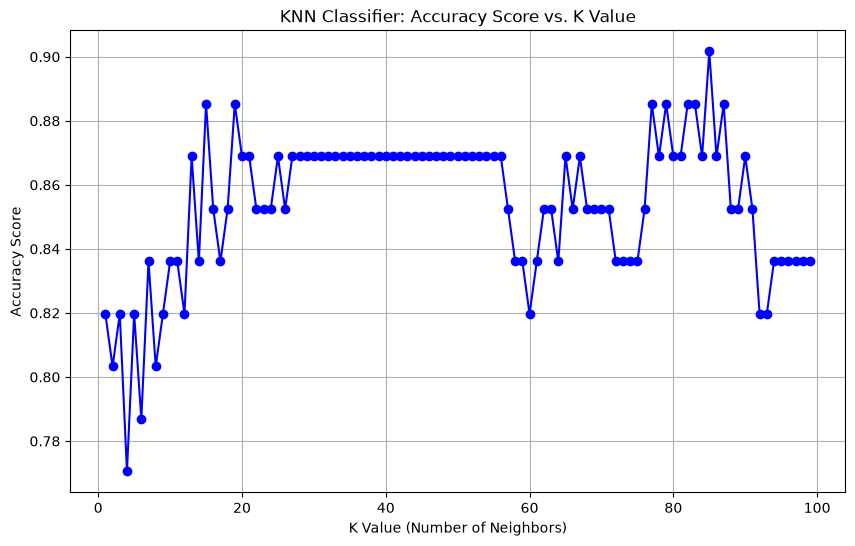

In [32]:
k_values = [i for i in range(1, 100)]
scores = []
for k in k_values:
    knn = KNeighborsClassifier(k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    scores.append(accuracy)

plt.figure(figsize=(10, 6))
plt.plot(k_values, scores, marker='o', linestyle='-', color='b')
plt.title('KNN Classifier: Accuracy Score vs. K Value')
plt.xlabel('K Value (Number of Neighbors)')
plt.ylabel('Accuracy Score')
plt.grid(True)
plt.show()

In [ ]:
optimal_k = k_values[np.argmax(scores)]
knn = KNeighborsClassifier(optimal_k)
knn.fit(X_train, y_train)
pred = knn.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 90.16%
